# Semantic Segmentation with PyTorch and U-Net
> https://www.kaggle.com/code/shnakazawa/semantic-segmentation-with-pytorch-and-u-net#Define-Helper-Functions
> https://zenn.dev/aidemy/articles/a43ebe82dfbb8b

## Import Modules

In [1]:
import os
import numpy as np
import pandas as pd
import math
import time
import random
import gc
from pathlib import Path
import cv2
from tqdm.notebook import tqdm
from sklearn.model_selection import KFold

# Image augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Modeling
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

print(f'PyTorch version {torch.__version__}')
print(f'Albumentations version {A.__version__}')

/Users/atsushi-takahiro@cookpad.com/hobby/kaggle_notebook/.venv/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


PyTorch version 2.7.0
Albumentations version 2.0.7


## Set Configs
Separately configuring settings such as objectives for running, file paths, hyperparameters, and other parameters can greatly aid in maintaining a clear and organized workflow.

In [4]:
RUN_EDA = True
RUN_TRAINING = True
TRAIN_ALL = False # If true, train with all data and output a single model. If False, run cross-validation and output multiple models.
FOLD_NUM = 5 # For cross-validation
EPOCHS = 20 # Training cycle
RUN_INFERENCE = False

# Directory setting
DATA_DIR = '/Users/atsushi-takahiro@cookpad.com/hobby/datasets/sartorius-cell-instance-segmentation/'
MODEL_DIR = '/Users/atsushi-takahiro@cookpad.com/hobby/datasets/working/'
IMG_SAVE_DIR = '/Users/atsushi-takahiro@cookpad.com/hobby/datasets/working/'

# PyTorch variables
SEED = 42
NUM_WORKERS = 2
BATCH_SIZE = 8
WEIGHT_DECAY = 0.0001
LR = 0.0001
MOMENTUM = 0.9

# Threshold for mask prediction
THRESHOLD = 0.3

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') 
print(f'Using {device} device')

Using mps device


## Define Helper Functions
Defining reusable functions at the beginning of a Jupyter Notebook can result in code that is cleaner, more organized, and more efficient.

In [3]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

# Set seed
seed_everything(SEED)


def show_gpu_memory(device):
    print(f"Allocated GPU memory: {torch.cuda.memory_allocated(device) / 1024 / 1024:.2f} MB")
    print(f"Cached GPU memory: {torch.cuda.memory_cached(device) / 1024 / 1024:.2f} MB")    

    
def load_img(path):
    img_bgr = cv2.imread(path)
    img_rgb = img_bgr[:, :, ::-1]
    return img_rgb


def group_bboxes(df):
    df_ = df.copy()
    df_['segment_count'] = 1
    df_ = df_.groupby(['id', 'width', 'height', 'cell_type']).count().reset_index()
    return_df = df_[['id', 'width', 'height', 'cell_type', 'segment_count']]
    return return_df


def create_gallery(array, ncols=3):
    """Display multiple images in a gallery style.
    Source: https://www.amazon.co.jp/Data-Analysis-Machine-Learning-Kaggle-ebook/dp/B09F3STL34/
    
    Args:
        array (numpy.ndarray): array of images.
        ncols (int, optional): Num of columns. Defaults to 3.

    Returns:
        numpy.ndarray: One concatenated image.
    """    
    nindex, height, width, intensity = array.shape
    nrows = nindex//ncols
    assert nindex == nrows * ncols
    result = (array.reshape(nrows, ncols, height, width, intensity)
        .swapaxes(1,2)
        .reshape(height*nrows, width*ncols, intensity))
    return result


def decode_rle(rle, height, width):
    """RLE to image
    modified from: https://www.kaggle.com/paulorzp/run-length-encode-and-decode

    Args:
        rle (str): mask with run length encoding.
        height (int): return image height.
        width (int): return image width.
        brightness (int): brightness of the pixel. Default to 1.

    Returns:
        np.ndarray: 1(b) - mask, 0 - background.
    """    
    s = rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(height * width, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1 # brightness
    return img.reshape((height, width)) 


def create_mask_image(image, masks):
    """Create a mask image from RLE.

    Args:
        image (numpy.ndarray): array of images.
        masks (list): List with RLE-encoded mask information.
        b (int): brightness of the pixel. Default to 1.
    
    Returns:
        numpy.ndarray: 1(b) - mask, 0 - background.
    """    
    
    s = image.shape
    h = s[0]
    w = s[1]
    mask_image = np.zeros((h,w))
    for mask in masks:
        mask_image += decode_rle(mask, h, w)
    mask_image = mask_image.clip(0, 1)
    return mask_image


def show_validation_score(train_loss_list, valid_loss_list, save=False, save_dir=IMG_SAVE_DIR, save_name='segmentation_validation_score.png'):
    fig = plt.figure(figsize=(10,10))
    for i in range(FOLD_NUM):
        train_loss = train_loss_list[i]
        valid_loss = valid_loss_list[i]
        
        ax = fig.add_subplot(math.ceil(np.sqrt(FOLD_NUM)), math.ceil(np.sqrt(FOLD_NUM)), i+1, title=f'Fold {i+1}')
        ax.plot(range(EPOCHS), train_loss, c='orange', label='train')
        ax.plot(range(EPOCHS), valid_loss, c='blue', label='valid')
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
    
    plt.tight_layout()
    if save:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_dir+save_name)
    else:
        plt.show()


def encode_rle(predicted_img):
    predicted_img = (predicted_img > THRESHOLD).astype(int)
    height, width = predicted_img.shape
    
    # Get the index of the masked pixel
    pixels = predicted_img.copy()
    pixels_list = []
    for y in range(height):
        for x in range(width):
            if pixels[y][x] != 0:
                pixels_list.append(y * width + x)

    # RLE encoding
    rle_list = []
    start = pixels_list[0]
    count = 1
    for i in range(1, len(pixels_list)):
        if pixels_list[i] == pixels_list[i-1] + 1:
            count += 1
        else:
            rle_list.extend([start, count])
            start = pixels_list[i]
            count = 1
    rle_list.extend([start, count])
    
    rle_str = [str(x) for x in rle_list]
    return ' '.join(rle_str)

## Load and Reshape a Table

In [5]:
df = pd.read_csv(DATA_DIR + 'train.csv')
df.head()

,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


In [6]:
grouped_df = group_bboxes(df)
grouped_df.head()

,id,width,height,cell_type,segment_count
0,0030fd0e6378,704,520,shsy5y,395
1,0140b3c8f445,704,520,astro,108
2,01ae5a43a2ab,704,520,cort,36
3,026b3c2c4b32,704,520,cort,42
4,029e5b3b89c7,704,520,cort,34


## Exploratory Data Analysis (EDA)

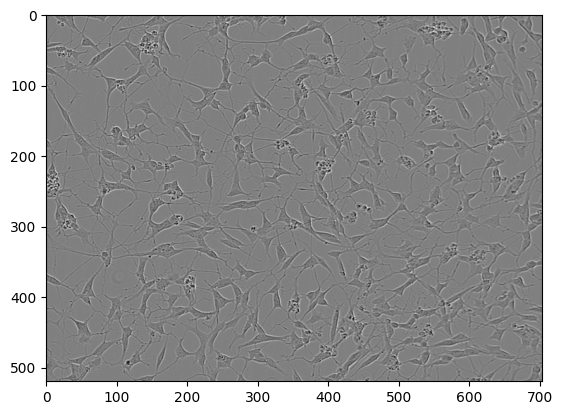

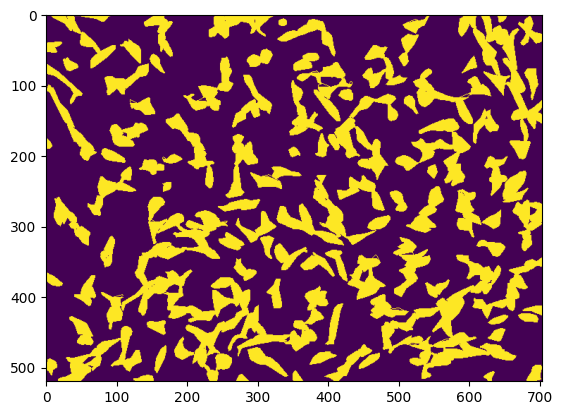

In [7]:
image_id = grouped_df['id'][0]
img = load_img(f'{DATA_DIR}train/{image_id}.png')
masks = df[df['id'] == image_id]['annotation'].tolist()
masked_img = create_mask_image(img, masks)
plt.figure()
plt.imshow(img)
plt.figure()
plt.imshow(masked_img)

## Model strategy
モデルコンポーネントの定義
本稿ではPyTorchを用いて物体認識モデルを実装します。PyTorchでの機械学習は一般に以下のような流れで行います。

1. 画像の変形・Augmentationの定義
2. Datasetの定義
3. Dataloaderの定義
4. Modelの定義
5. 学習の実行


## Data agumentation

In [8]:
# Image Transformation & Augmentation
def transform_train():
    transforms = [
        A.Resize(256,256,p=1),
        A.HorizontalFlip(p=0.5),
        A.Transpose(p=0.5),
        ToTensorV2(p=1)
    ]
    return A.Compose(transforms)


# Validation images undergo only resizing.
def transform_valid():
    transforms = [
        A.Resize(256,256,p=1),
        ToTensorV2(p=1)
    ]
    return A.Compose(transforms)


## Define Dataset
PyTorchにおける Dataset は、機械学習モデルの訓練や評価のためにデータを準備・抽象化するための重要なコンポーネントです。その主な役割は以下の通りです。

1. データソースの抽象化:
    - データがどこに保存されているか（例: ディスク上の画像ファイル、CSVファイル、データベース、ウェブAPIなど）に関わらず、Dataset クラスはデータを一貫した方法でアクセスするためのインターフェースを提供します。これにより、データソースの詳細をモデルの訓練ロジックから分離できます。
2. データサンプルへのアクセス:
    - Dataset クラスは、Pythonの `__len__` メソッドと `__getitem__` メソッドを実装する必要があります。
        - `__len__` メソッドは、データセットに含まれるサンプルの総数を返します。
        - `__getitem__` メソッドは、与えられたインデックス（idx）に対応する単一のデータサンプル（例: 画像とそのラベルのペア）を返します。これにより、データセット内の任意のサンプルにインデックスを使ってアクセスできるようになります。
3. データの前処理と変換（Transformations）:
    - Dataset の __getitem__ メソッド内で、データをモデルが期待する形式に変換する処理を記述できます。これには、画像のサイズ変更、正規化、データ拡張（オーグメンテーション）などが含まれます。
    - 例えば、ご提示のAlbumentationsの変換処理は、この Dataset クラスの内部で適用されるように設計されます。具体的には、__getitem__ メソッド内で画像を読み込み、定義された変換パイプライン（transform_train や transform_valid）を適用してから、テンソルとして返す形になります。
4. DataLoader との連携:
    - Dataset オブジェクトは、通常 torch.utils.data.DataLoader クラスと共に使用されます。DataLoader は Dataset からデータサンプルを受け取り、それらをバッチにまとめてモデルに供給する役割を担います。
    - DataLoader は、バッチ処理、データのシャッフル、マルチプロセスによるデータ読み込み（num_workers 引数）といった便利な機能を提供し、効率的な訓練を可能にします。

まとめると ***Dataset は、生データとモデルの間に立つ橋渡し役のようなもの**です。データをどこから、どのように取得し、どのような前処理や変換を施して、モデルに渡せるような単一のサンプルとして準備するか、というロジックをカプセル化します。これにより、モデルの訓練ループはデータソースや前処理の詳細から解放され、よりクリーンで再利用可能なコードになります。

In [10]:
# Dataset
class CellDataset(Dataset):
    def __init__(self, image_ids, dataframe, data_root, transforms=None, stage='train'):
        super().__init__()
        self.image_ids = image_ids
        self.dataframe = dataframe
        self.data_root = data_root
        self.transforms = transforms
        self.stage = stage

    def __len__(self):
        return self.image_ids.shape[0]
    
    def __getitem__(self, index):
        image_id = self.image_ids[index]
        # Load images
        image  = load_img(f'{self.data_root}{image_id}.png').astype(np.float32)

        # 3 channels to 1 channel
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        image /= 255.0 # normalization

        # For training and validation
        if self.stage == 'train':
            # masks
            masks = self.dataframe[self.dataframe['id'] == image_id]['annotation'].tolist()
            mask_image = create_mask_image(image, masks)

            # Transform images and masks
            if self.transforms:
                transformed = self.transforms(image=image, mask=mask_image)
                image, mask_image = transformed['image'], transformed['mask']
            return image, mask_image, image_id
        
        # For test
        else:
            # Transform images
            if self.transforms:
                image =self.transforms(image=image)['image']
            
            return image, image_id

## Define dataloader

In [12]:
# DataLoader
def create_dataloader(grouped_df, df, trn_idx, val_idx):
    train_ = grouped_df.loc[trn_idx,:].reset_index(drop=True)
    valid_ = grouped_df.loc[val_idx,:].reset_index(drop=True)

    # Dataset
    train_datasets = CellDataset(train_['id'].to_numpy(), df, DATA_DIR+'train/', transforms=transform_train())
    valid_datasets = CellDataset(valid_['id'].to_numpy(), df, DATA_DIR+'train/', transforms=transform_valid())

    # Data Loader
    train_loader = DataLoader(train_datasets, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True, multiprocessing_context='fork')
    valid_loader = DataLoader(valid_datasets, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False, multiprocessing_context='fork')

    return train_loader, valid_loader

## Define model

In [13]:
class DoubleConv(nn.Module):
    """DoubleConv is a basic building block of the encoder and decoder components. 
    Consists of two convolutional layers followed by a ReLU activation function.
    """    
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.double_conv(x)
        return x


class Down(nn.Module):
    """Downscaling.
    Consists of two consecutive DoubleConv blocks followed by a max pooling operation.
    """    
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        x = self.maxpool_conv(x)
        return x


class Up(nn.Module):
    """Upscaling.
    Performed using transposed convolution and concatenation of feature maps from the corresponding "Down" operation.
    """
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # input tensor shape: (batch_size, channels, height, width)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x
    

class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, bilinear=False):
        super(UNet, self).__init__()
        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        
        self.down4 = Down(512,1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.outc(x)
        x = torch.sigmoid(x)
        return x

## Train and evaluate

In [14]:
if TRAIN_ALL: # TRAIN_ALLという変数で条件を分岐。Trueなら全データで学習。
    # Train with all data
    folds = [['','']]
else: 
    # Cross validation
    folds = KFold(n_splits=FOLD_NUM, shuffle=True, random_state=SEED)\
            .split(np.arange(grouped_df.shape[0]), grouped_df['id'].to_numpy())
    
    # For Visualization
    train_loss_list = []
    valid_loss_list = []


for fold, (trn_idx, val_idx) in enumerate(folds):
    # Load Data   
    if TRAIN_ALL:
        train_datasets = CellDataset(grouped_df['id'].to_numpy(), df, DATA_DIR+'train/', transforms=transform_train())
        train_loader = DataLoader(train_datasets, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True, multiprocessing_context='fork')
    else:
        print(f'==========Cross-Validation Fold {fold+1}==========')   
        train_loader, valid_loader = create_dataloader(grouped_df, df, trn_idx, val_idx)
        # For Visualization
        valid_losses = []

    train_losses = []
    # Load model, loss function, and optimizing algorithm
    model = UNet().to(device)
    criterion = nn.BCELoss().to(device)
    optimizer = optim.SGD(model.parameters(), weight_decay=WEIGHT_DECAY, lr = LR, momentum=MOMENTUM)
    
    # Start training
    best_loss = 10**5
    for epoch in range(EPOCHS):
        time_start = time.time()
        print(f'==========Epoch {epoch+1} Start Training==========')
        model.train()
        train_loss = 0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader))
        for step, (imgs, masks, image_ids) in pbar:
            imgs = imgs.to(device).float()
            # imgs = torch.squeeze(imgs)
            masks = masks.to(device).float()
            masks = masks.view(imgs.shape[0], -1, 256, 256)

            optimizer.zero_grad()
            
            output = model(imgs)
            loss = criterion(output, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        if TRAIN_ALL == False:
            print(f'==========Epoch {epoch+1} Start Validation==========')
            
            with torch.no_grad():
                valid_loss = 0
                preds = []
                pbar = tqdm(enumerate(valid_loader), total=len(valid_loader))
                for step, (imgs, masks, image_ids) in pbar:
                    imgs = imgs.to(device).float()
                    # imgs = torch.squeeze(imgs)
                    masks = masks.to(device).float()
                    masks = masks.view(imgs.shape[0], -1, 256, 256)
            
                    val_output = model(imgs)
                    val_loss = criterion(val_output, masks)
                    
                    valid_loss += val_loss.item()
                valid_loss /= len(valid_loader)
                
        # print results from this epoch
        exec_t = int((time.time() - time_start)/60)
        if TRAIN_ALL:
            print(f'Epoch : {epoch+1} - loss : {train_loss:.4f} / Exec time {exec_t} min\n')

        else:
            print(
                f'Epoch : {epoch+1} - loss : {train_loss:.4f} - val_loss : {valid_loss:.4f} / Exec time {exec_t} min\n'
            )
            # For visualization
            train_losses.append(train_loss)
            valid_losses.append(valid_loss)
    
    if TRAIN_ALL:
        print(f'Save model trained with all data')
        os.makedirs(MODEL_DIR, exist_ok=True)
        torch.save(model.state_dict(), MODEL_DIR+'segmentation.pth')
        del model, optimizer, train_loader
    else:
        train_loss_list.append(train_losses)
        valid_loss_list.append(valid_losses)
        del model, optimizer, train_loader, valid_loader, train_losses, valid_losses
    gc.collect()
    torch.cuda.empty_cache()

if TRAIN_ALL == False:
    # Define Helper Functions内で定義
    show_validation_score(train_loss_list, valid_loss_list)

==========Cross-Validation Fold 1==========
==========Epoch 1 Start Training==========


ERROR: Unexpected segmentation fault encountered in worker.
 ERROR: Unexpected segmentation fault encountered in worker.
 

RuntimeError: DataLoader worker (pid 21803) is killed by signal: Segmentation fault: 11. 